# Basic Pipeline

2026-07-21

In [ ]:
options(repr.plot.format = "png", jupyter.plot_mimetypes = "image/png")

In [ ]:
library(Seurat)
library(harmony)
library(ggplot2)

set.seed(42) # for reproducibility


data_path <- file.path("data", "basic_analysis/")
save_path <- file.path(".", "basic_analysis/")

if (!dir.exists(save_path)) {
  dir.create(save_path)
}

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: Rcpp

• This is Harmony2 version 2.0.5
• Read the guide: run vignette("quickstart", package="harmony")
• Get help: Visit the website at <https://korsunskylab.github.io/harmony2/> and
report issues on <https://github.com/immunogenomics/harmony/issues>
Warning message in dir.create(save_path):
“cannot create dir 'work/basic_analysis', reason 'No such file or directory'”


## Load data

The data used in this example is from the paper [Sikkema, L. et al. (2023)](https://doi.org/10.1038/s41591-023-02327-2).
This data can be accessed through this [collection](https://cellxgene.cziscience.com/collections/6f6d381a-7701-4781-935c-db10d30de293) on the Cellxgene platform. 
In this example however, we will use the sampled version of this data. 
Therefore, we set `min.cells` and `min.features` to 0, avoiding any further filtering.

In [3]:
count_matrix <- read.csv(paste0(data_path, "HLCA_pulmonary_fibrosis_immune_raw.csv"), row.names = 1)
meta.data <- read.csv(paste0(data_path, "HLCA_pulmonary_fibrosis_immune_meta.csv"), row.names = 1)

# so stands for 's'eurat 'o'bject 
so <- CreateSeuratObject(counts = count_matrix, meta.data = meta.data, assay = "RNA", min.cells = 0, min.features = 0, project = "HLCA_Pulmonary_Fibrosis_immune")
# genes are in rows, cells are in columns


Warning message:
“Data is of class data.frame. Coercing to dgCMatrix.”


In [4]:
head(so, n = 3)

,orig.ident,nCount_RNA,nFeature_RNA,disease,study
,<fct>,<dbl>,<int>,<chr>,<chr>
F01173_GCTGGGTTCCTGTAGA_haberman,HLCA_Pulmonary_Fibrosis_immune,5525,1877,pulmonary fibrosis,Banovich_Kropski_2020
F00431_CTAGAGTCATGCCACG_haberman,HLCA_Pulmonary_Fibrosis_immune,2784,1017,pulmonary fibrosis,Banovich_Kropski_2020
F01172_AGTAGTCGTCCGACGT_haberman,HLCA_Pulmonary_Fibrosis_immune,1617,1012,pulmonary fibrosis,Banovich_Kropski_2020


## Normalization

### Seurat style

In seurat, we can perform normalization like below.

In [5]:
so[["RNA"]] <- split(so[["RNA"]], f = so$study)
so <- NormalizeData(so)

Normalizing layer: counts.Banovich_Kropski_2020

Normalizing layer: counts.Kaminski_2020

Normalizing layer: counts.Misharin_Budinger_2018

Normalizing layer: counts.Sheppard_2020



### Scran style

In scran, we can perform normalization like below.

```R
# convert from Seurat object to SingleCellExperiment object
sce <- as.SingleCellExperiment(so)

clusters <- quickCluster(sce)
sce <- computeSumFactors(sce, clusters = clusters)
sce.norm <- logNormCounts(sce, pseudo.count = 1)

gene_variance <- modelGeneVar(sce.norm)

hvg.norm <- getTopHVGs(gene_variance, fdr.threshold = 0.05)

# and convert back to Seurat object
so <- as.Seurat(
    sce.norm,
    counts = "counts",
    data = "logcounts",
)
VariableFeatures(so) <- hvg.norm
```

### Batch-aware feature selection

Selecting highly variable genes (HVGs) as a feature set is a common practice in single-cell RNA-seq analysis.
However, this data consists of samples across multiple studies, potentially introducing batch effects.
This kind of across-study batch effect can mask the real biological signal of interest.
To address this, we must take the batch information into account when selecting HVGs.

Here, we'll leverage this batch-aware feature implemented by `Seurat`.

In [6]:
so <- FindVariableFeatures(so, selection.method = "vst", nfeatures = 2000)

Finding variable features for layer counts.Banovich_Kropski_2020

Finding variable features for layer counts.Kaminski_2020

Finding variable features for layer counts.Misharin_Budinger_2018

Finding variable features for layer counts.Sheppard_2020



## Dimensionality Reduction

Based on the HVGs selected in the previous step, we can perform dimensionality reduction using PCA.

In [7]:
all.genes <- rownames(so)
so <- ScaleData(so, features = all.genes)
so <- RunPCA(so, features = VariableFeatures(so))

Centering and scaling data matrix

PC_ 1 
Positive:  CD69, CCL5, IL32, CST7, NKG7, CD7, GZMA, GZMB, CD247, PRF1 
	   CD3E, CD2, KLRD1, GNLY, CTSW, CD3D, SYNE2, KLRB1, AC243829.1.CCL4, CD96 
	   GZMH, HOPX, GZMM, RHOH, IFITM1, RORA, DUSP2, ITK, PYHIN1, LOC100130872.SPON2 
Negative:  FTL, GRN, CTSB, PSAP, CST3, NPC2, FCER1G, GPX1, SPI1, CD74 
	   MARCO, GLUL, FCGRT, TYROBP, ANXA5, CTSS, ASAH1, APOC1, ACP5, LGALS3 
	   CTSL, CTSZ, FBP1, SLC11A1, CSTB, MRC1.MRC1L1, GPNMB, C1QA, C1QC, C1QB 
PC_ 2 
Positive:  ELL2, SLC16A10, CCSER1, MS4A6E, FMN1, PDE8A, SH3PXD2B, SNTB1, KYNU, FGD4 
	   ATP13A3, FMNL2, PLXDC2, GPCPD1, SLC8A1, ABCA1, TNS3, RP11.381O7.3.RP11.236F9.2.ENSG00000261522.AL845321.1.MTHFD1L.ENSG00000182021.LOC100133920.ENSG00000184906.ENSG00000228522.AL591379.1, PELI1, LINC00854.CCDC200 
	   DNMBP, B4GALT1, TANC2, MOB3B, LSAMP, RASAL2, UBE2E2, FHIT, AMZ1, TBC1D8 
Negative:  FTH1, CTSD, UBB, SH3BGRL3, ACTB, CD68, TUBA1B, PRDX1, MS4A7, HMGN2 
	   TMSB4X, TMSB10, ARL6IP1, MYL6, LYZ, GCHF

In [8]:
options(repr.plot.width = 4, repr.plot.height = 4)

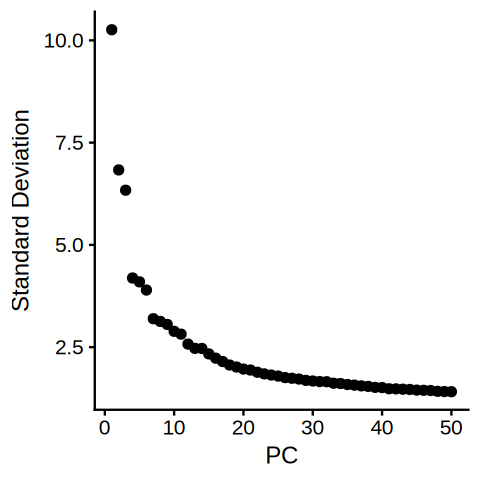

In [9]:
ElbowPlot(so, ndims = 50)

In [10]:
PCs <- 10

so <- FindNeighbors(so, dims = 1:PCs)
so <- FindClusters(so, resolution = 0.5)

so <- RunUMAP(so, dims = 1:PCs)
# so <- RunTSNE(so, dims = 1:PCs)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 7782
Number of edges: 256622

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9222
Number of communities: 17
Elapsed time: 0 seconds


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
01:24:32 UMAP embedding parameters a = 0.9922 b = 1.112

01:24:32 Read 7782 rows and found 10 numeric columns

01:24:32 Using Annoy for neighbor search, n_neighbors = 30

01:24:32 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

01:24:33 Writing NN index file to temp file /tmp/RtmpY5a9CT/file1f5714347f2f

01:24:33 Searching Annoy index using 1 thread, search_k = 3000

01:24:35 Annoy recall = 100%

01:24:35 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors =

In [11]:
options(repr.plot.width = 8, repr.plot.height = 6)

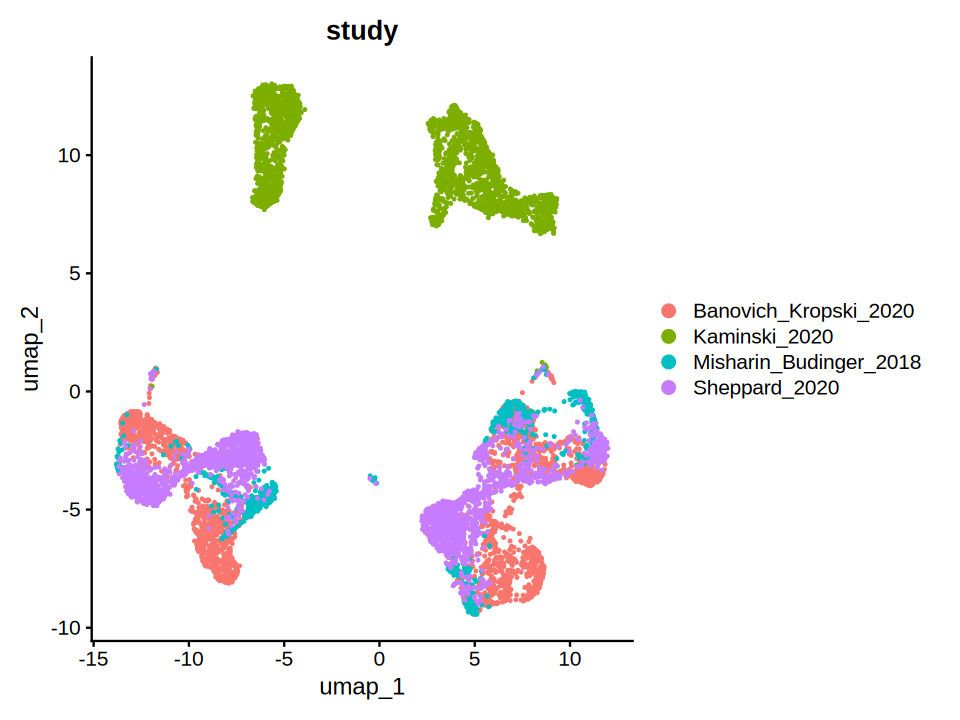

In [12]:
DimPlot(so, group.by = "study")

## Batch Correction by Harmony

We can correct the batch effects using the method from the paper [Korsunsky, I. et al. (2019)](https://doi.org/10.1038/s41592-019-0619-0).
You can find out more about this method in its [documentations](https://portals.broadinstitute.org/harmony/articles/quickstart.html).

In [13]:
so <- RunHarmony(so, "study")
so <- FindNeighbors(so, reduction = "harmony")
so <- FindClusters(so, resolution = 0.5) 
so <- RunUMAP(so, dims = 1:PCs, reduction = "harmony", reduction.name = "umap.harmony") # use same dimension number as before
# so <- RunTSNE(so, dims = 1:PCs, reduction = "harmony", reduction.name = "tsne.harmony")

Transposing data matrix

Using automatic lambda estimation

Thetas: 2

Initializing state using k-means centroids initialization



Initializing centroids


Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony 6/10

Harmony converged after 6 iterations

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 7782
Number of edges: 261813

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8842
Number of communities: 10
Elapsed time: 0 seconds


01:24:53 UMAP embedding parameters a = 0.9922 b = 1.112

01:24:53 Read 7782 rows and found 10 numeric columns

01:24:53 Using Annoy for neighbor search, n_neighbors = 30

01:24:53 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

01:24:54 Writing NN index file to temp file /tmp/RtmpY5a9CT/file1f572679f744

01:24:54 Searching Annoy index using 1 thread, search_k = 3000

01:24:56 Annoy recall = 100%

01:24:56 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

01:24:57 Initializing from normalized Laplacian + noise (using RSpectra)

01:24:57 Commencing optimization for 500 epochs, with 318556 positive edges

01:24:57 Using rng type: pcg

01:25:07 Optimization finished



In [14]:
options(repr.plot.width = 8, repr.plot.height = 6)

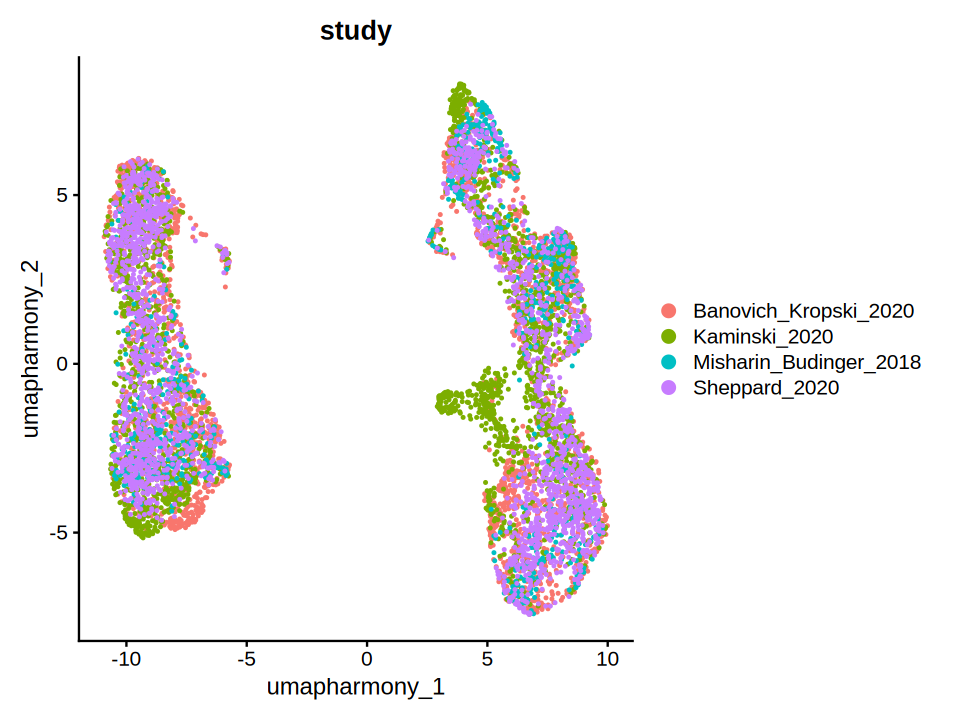

In [15]:
DimPlot(so, group.by = "study", reduction = "umap.harmony")

In [16]:
options(repr.plot.width = 8, repr.plot.height = 6)

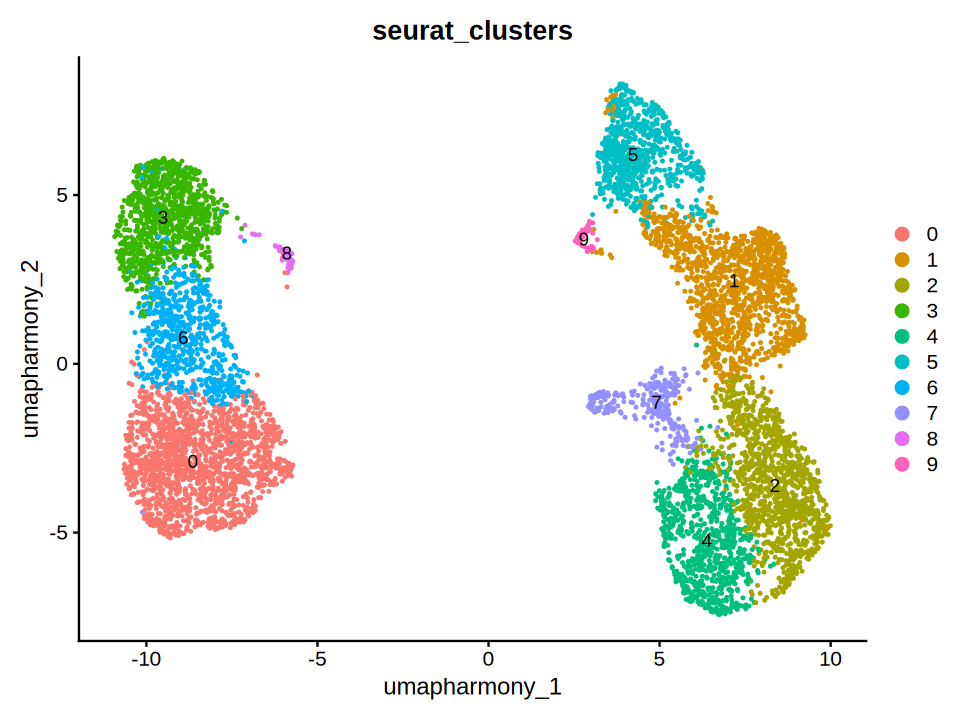

In [17]:
DimPlot(so, group.by = "seurat_clusters", reduction = "umap.harmony", label = TRUE)

### Automatic cell type annotation

We can perform automatic cell type annotation using celltypist, which is a machine learning-based method for cell type annotation. However, we won't go into the details of this method in this example. 

```py
import scanpy as sc
import celltypist

# reference
adata_ref = adata_ref.copy()
adata_ref.X = adata_ref.layers["counts"].copy()
sc.pp.normalize_total(adata_ref, target_sum=1e4)
sc.pp.log1p(adata_ref)

new_model = celltypist.train(adata_ref, labels="cell_type", n_jobs=10, feature_selection=True)

model_path = "celltypist_custom_model.pkl"
new_model.write(model_path)

# object to annotate
adata_annot = adata_annot.copy()
adata_annot.X = adata_annot.layers["counts"].copy()
sc.pp.normalize_total(adata_annot, target_sum=1e4)
sc.pp.log1p(adata_annot)

predictions = celltypist.annotate(adata_annot, model=model_path, majority_voting=False)
predictions.predicted_labels.to_csv("predicted_labels.csv")
```

## Visualize marker gene expression

In [18]:
options(repr.plot.width = 13, repr.plot.height = 9)

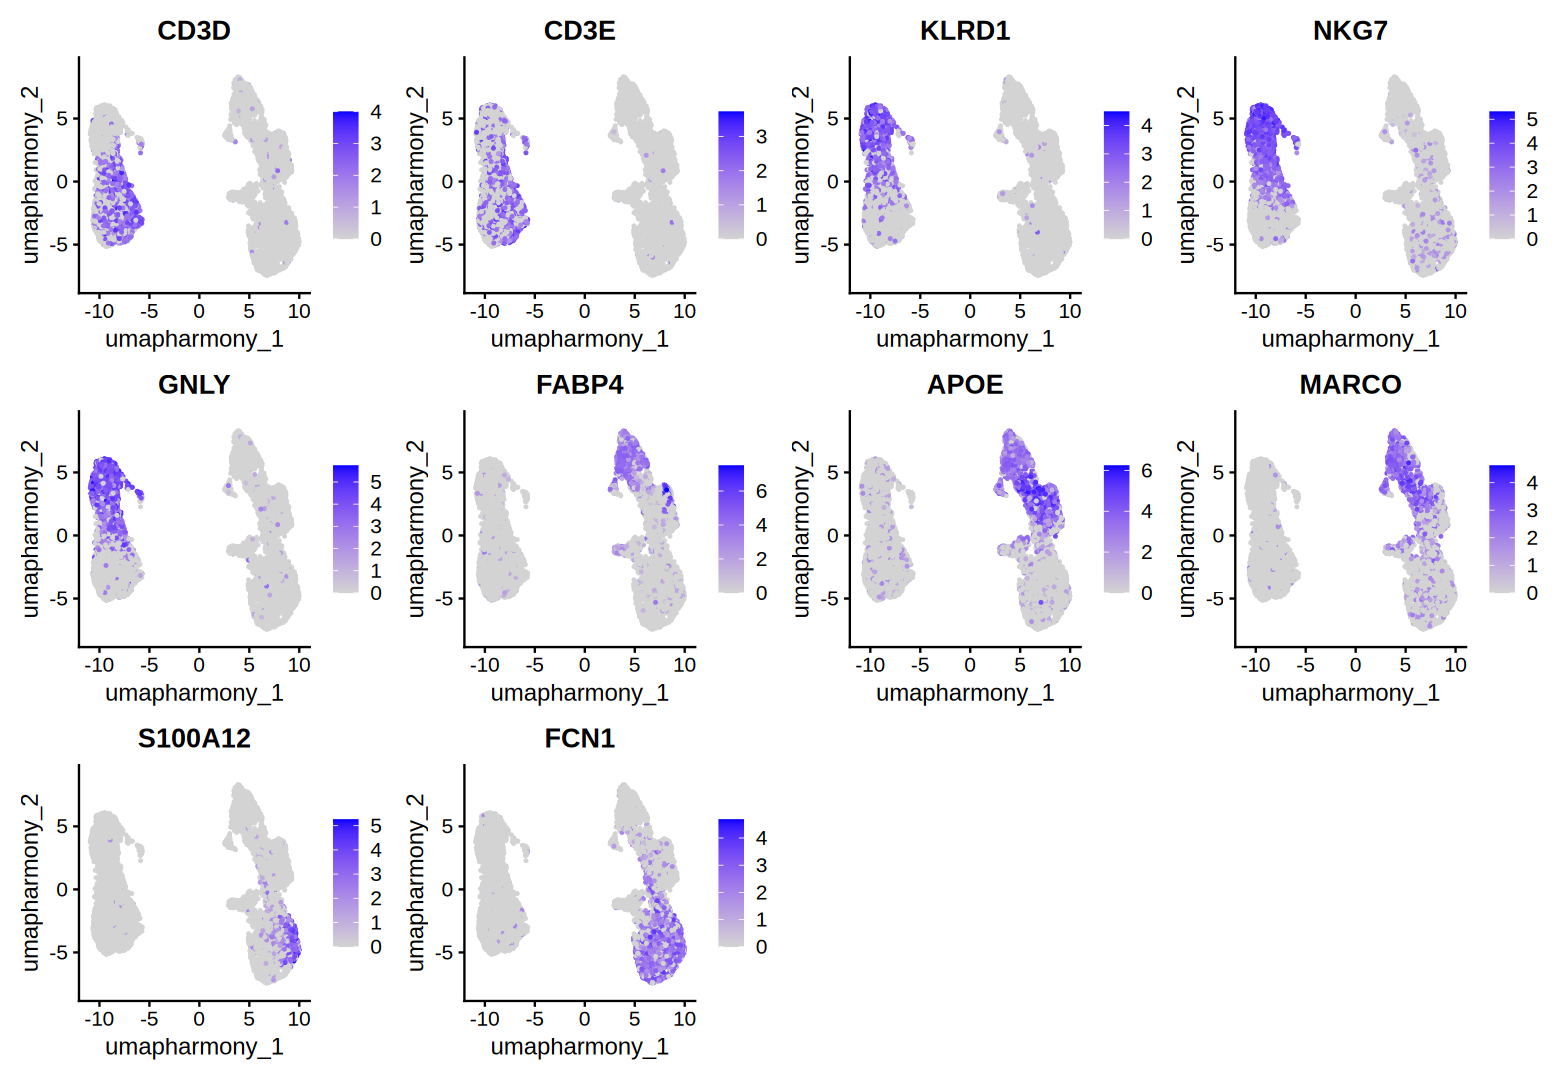

In [19]:
marker.genes <- list(
    T.cell = c("CD3D", "CD3E"),
    NK.cell = c("KLRD1", "NKG7", "GNLY"),
    Macrophage = c("FABP4", "APOE", "MARCO"),
    Monocyte = c("S100A12", "FCN1")
)

FeaturePlot(so, features = unlist(marker.genes), ncol = 4, reduction = "umap.harmony")

In [20]:
options(repr.plot.width = 8, repr.plot.height = 5)

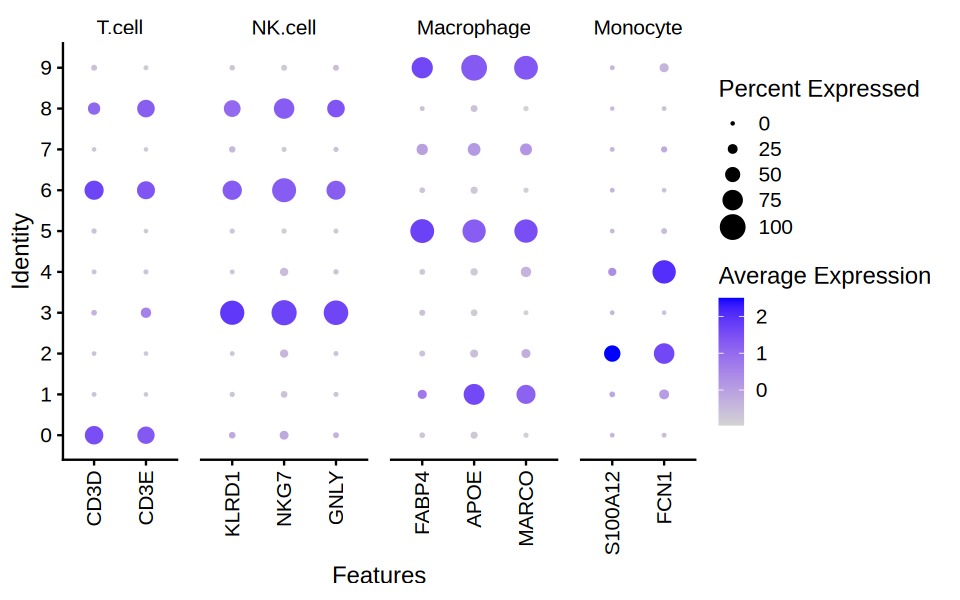

In [21]:
DotPlot(so, features = marker.genes, group.by = "seurat_clusters") +
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

In [22]:
options(repr.plot.width = 8, repr.plot.height = 6)

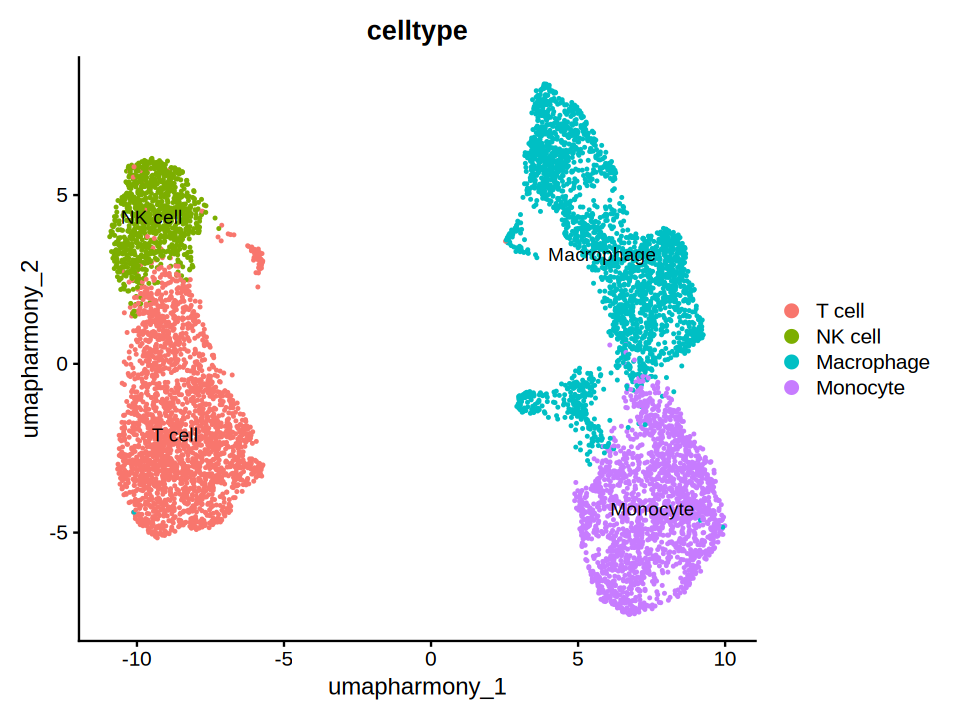

In [23]:
so$celltype <- as.character(so$seurat_clusters)
so$celltype[so$celltype %in% c(0, 6, 8)] <- "T cell"
so$celltype[so$celltype %in% c(3)] <- "NK cell"
so$celltype[so$celltype %in% c(1, 5, 7, 9)] <- "Macrophage"
so$celltype[so$celltype %in% c(2, 4)] <- "Monocyte"
so$celltype = factor(so$celltype, levels = c("T cell", "NK cell", "Macrophage", "Monocyte"))

DimPlot(so, group.by = "celltype", reduction = "umap.harmony", label = TRUE)

In [24]:
options(repr.plot.width = 8, repr.plot.height = 4)

Warning message:
“Scaling data with a low number of groups may produce misleading results”


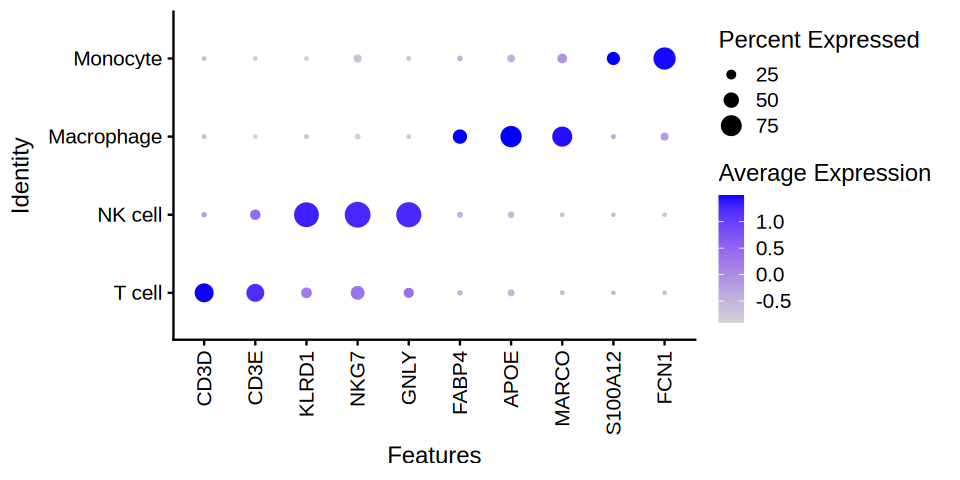

In [25]:
DotPlot(so, features = as.vector(unlist(marker.genes)), group.by = "celltype") +
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

In [26]:
so <- JoinLayers(so)

## Selecting patient-aware differentially expressed genes (DEGs)

In [27]:
donor_id <- read.csv(paste0(data_path, "HLCA_pulmonary_fibrosis_donor_subset.csv"), row.names = 1)
so$donor.id <- donor_id[Cells(so), ]

In [28]:
library(EnhancedVolcano)

Tcells.control <- Cells(so)[so$celltype == "T cell" & so$disease == "normal"]
Tcells.pulmonary <- Cells(so)[so$celltype == "T cell" & so$disease == "pulmonary fibrosis"]

DEG.vanilla <- FindMarkers(so, ident.1 = Tcells.pulmonary, ident.2 = Tcells.control)

Loading required package: ggrepel



In [29]:
options(repr.plot.width = 8, repr.plot.height = 6)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”


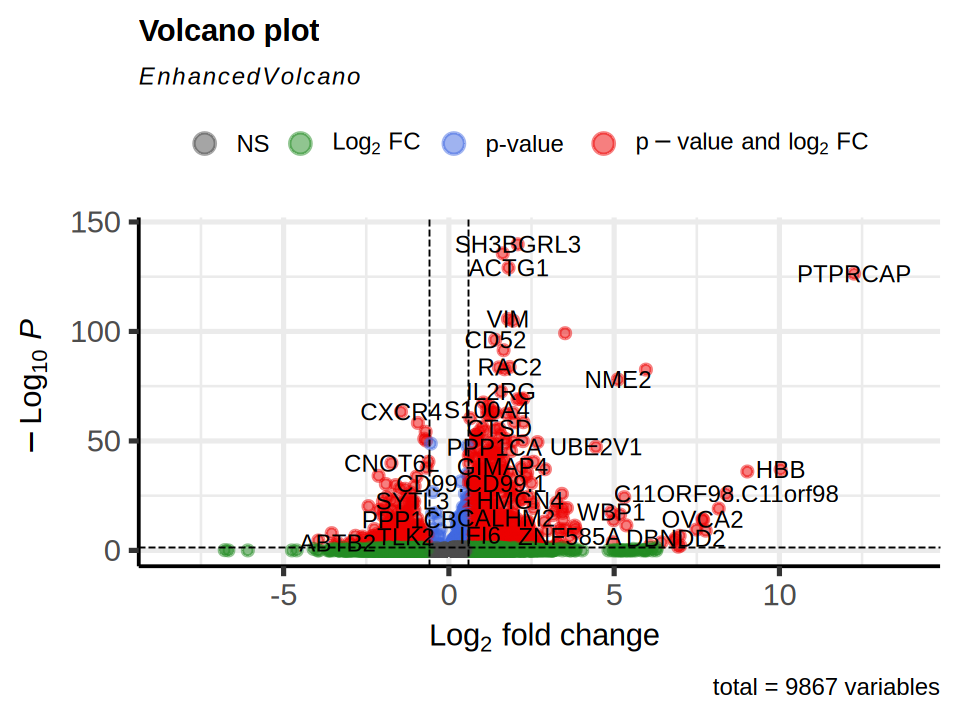

In [30]:
EnhancedVolcano(DEG.vanilla, lab = rownames(DEG.vanilla), x = "avg_log2FC", y = "p_val_adj", FCcutoff = log2(1.5), pCutoff = 0.05)

In [31]:
Tcells <- so[, c(Tcells.control, Tcells.pulmonary)]
donor_cell_count <- table(Tcells$donor.id)
donors_keep <- names(donor_cell_count[donor_cell_count >= 10])
cells_keep <- Cells(Tcells)[as.character(Tcells$donor.id) %in% donors_keep]
Tcells <- Tcells[, cells_keep]

pb_counts <- AggregateExpression(
  Tcells, group.by = "donor.id", assays = "RNA", return.seurat = FALSE
)$RNA
pb_meta <- unique(Tcells@meta.data[, c("donor.id", "disease")])
rownames(pb_meta) <- pb_meta$donor.id
pb_meta$disease <- factor(pb_meta$disease, levels = c("normal", "pulmonary fibrosis"))
rownames(pb_meta) <- gsub("_", "-", rownames(pb_meta))
pb_meta <- pb_meta[colnames(pb_counts), , drop = FALSE]

Names of identity class contain underscores ('_'), replacing with dashes ('-')
This message is displayed once every 8 hours.


In [32]:
library(DESeq2)

dds <- DESeqDataSetFromMatrix(
  countData = as.matrix(pb_counts),
  colData = pb_meta,
  design = ~ disease
)

dds <- DESeq(dds)
result <- results(
  dds, contrast = c("disease", "pulmonary fibrosis", "normal"), alpha = 0.05
)
DEG.deseq2 <- as.data.frame(result)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The follo

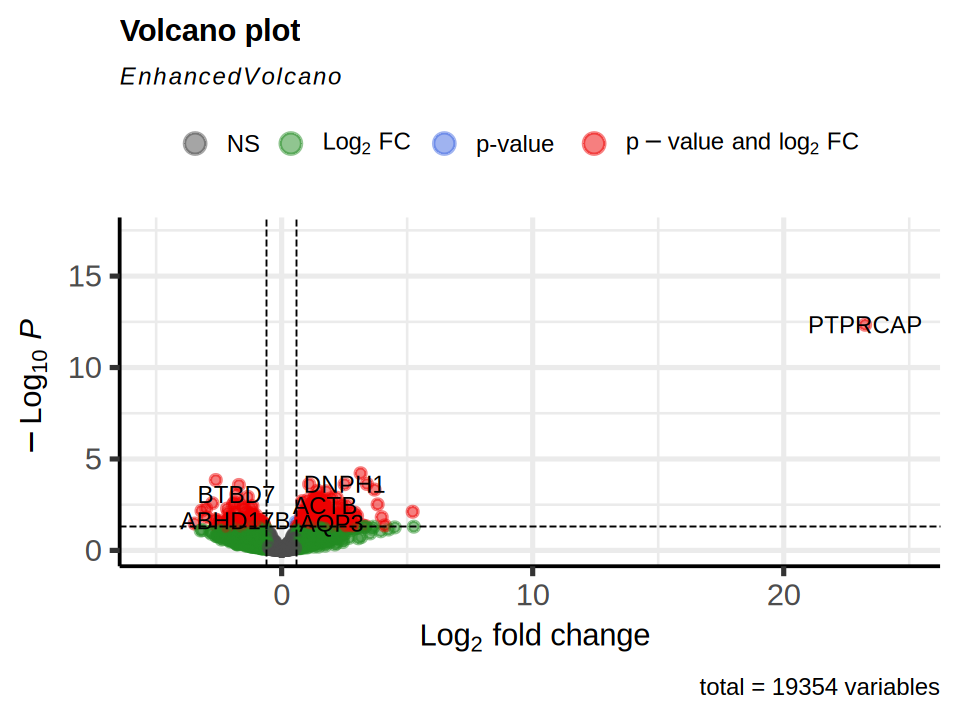

In [33]:
EnhancedVolcano(
  DEG.deseq2, lab = rownames(DEG.deseq2), x = "log2FoldChange", y = "padj", FCcutoff = log2(1.5), pCutoff = 0.05
)

In [34]:
sessionInfo()

R version 4.5.3 (2026-03-11)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 24.04.4 LTS

Matrix products: default
BLAS/LAPACK: /opt/conda/lib/libopenblasp-r0.3.33.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] DESeq2_1.50.2               SummarizedExperiment_1.40.0
 [3] Biobase_2.70.0              MatrixGenerics_1.22.0      
 [5] matrixStats_1.5.0           GenomicRanges_1.62.1       
 [7] Seqinfo_1.0.0               IRanges_2.44.0             
 [9] S4Vectors_0.48.1            BiocGenerics_0.56.0        
[11